In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from sklearn.linear_model import LinearRegression
from scipy import constants

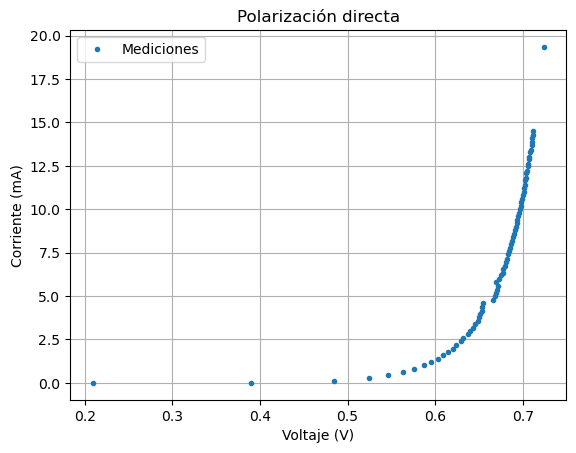

In [9]:
#Obtengo datos de la polarizacion directa
with open('Pdirecta.csv', mode='r') as archivo:
    directa = csv.reader(archivo) #Usamos la biblioteca csv
    next(directa,None)            #Me salto el primer renglón
    Vi_direc, Vd_direc, Id_direc = [], [], []
    for renglon in directa:
        Vi_direc.append(float(renglon[0]))
        Vd_direc.append(float(renglon[1]))
        Id_direc.append(float(renglon[2]))

#Obtengo datos de la polarizacion inversa
with open('Pinversa.csv', mode='r') as archivo:
    inversa = csv.reader(archivo) #Usamos la biblioteca csv
    next(inversa,None)
    Vi_inv, Vd_inv, Id_inv = [], [], []
    for renglon in inversa:
        Vi_inv.append(float(renglon[0]))
        Vd_inv.append(float(renglon[1]))
        Id_inv.append(float(renglon[2]))

#Función para graficar semilog sin problemas
def filtro_log(func_x, func_y):
    func_y_filtrada = []
    func_x_filtrada = []
    for i in range(len(func_y)):
        if func_y[i] > 0.001:
            func_y_filtrada.append(func_y[i])
            func_x_filtrada.append(func_x[i])
    return np.array(func_x_filtrada), np.array(func_y_filtrada)

plt.plot(Vd_direc,Id_direc,'.',label='Mediciones')
plt.title('Polarización directa')
plt.xlabel('Voltaje (V)'), plt.ylabel('Corriente (mA)')
#plt.axhline(y=1, color='red', linestyle='--', linewidth=0.8)
#plt.text(0.31,1.25,'I = 1')
plt.legend()
plt.grid()
plt.show()

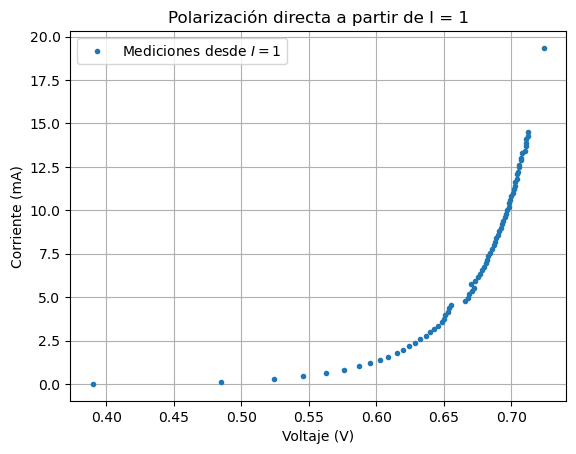

In [3]:
#Estos son los datos filtrados (los que usaremos para la grafica semilog) 

Vd_filt, Id_filt = filtro_log(Vd_direc,Id_direc)
#Vd_filt, Id_filt = Vd_direc, Id_direc

plt.plot(Vd_filt,Id_filt,'.',label=r'Mediciones desde $I = 1$')
plt.title('Polarización directa filtrada')
plt.xlabel('Voltaje (V)'), plt.ylabel('Corriente (mA)')
plt.grid()
plt.legend()
plt.show()

In [4]:
#Regresion lineal usando sklearn
Id_log = np.log(Id_filt)              #Para que la gráfica sea lineal
Vd_reshape = np.array(Vd_filt).reshape(-1,1)    #predict necesita un arreglo 2D

model = LinearRegression()
model.fit(Vd_reshape, Id_log)

#Regresion en escala logaritimica
Id_reg_log = model.predict(Vd_reshape)
#Volvemos a la escala "lineal'
Id_reg = np.exp(Id_reg_log)

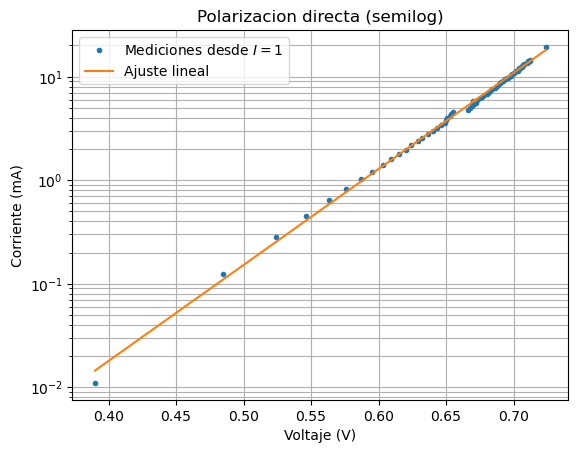

In [5]:
plt.semilogy(Vd_filt,Id_filt,'.',label=r'Mediciones desde $I = 1$')
plt.plot(Vd_filt,Id_reg,label='Ajuste lineal')
plt.title('Polarizacion directa (semilog)')
plt.xlabel('Voltaje (V)'), plt.ylabel('Corriente (mA)')
plt.grid(True, which="both", ls = '-')
plt.legend()
plt.show()

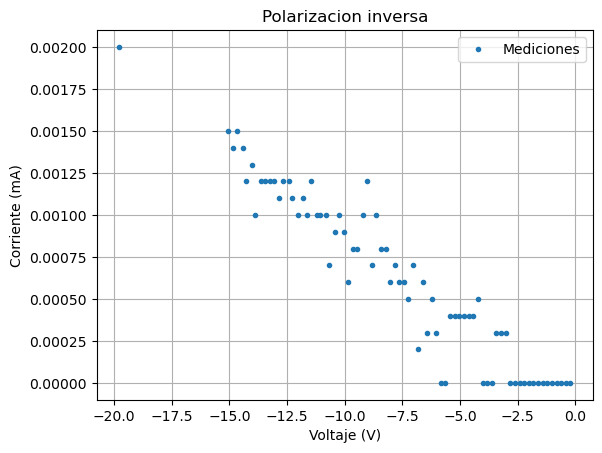

In [6]:
plt.plot(Vd_inv,Id_inv,'.',label='Mediciones')
plt.title('Polarizacion inversa')
plt.xlabel('Voltaje (V)'), plt.ylabel('Corriente (mA)')
plt.grid()
plt.legend()
plt.show()

In [7]:
m = model.coef_[0]     #m = pendiente = (e/kb) * 1/(T*N)
T = 26 + 273.15        #Temp en kelvin
n = 2
razon_experimental = m*T*n

#Calculo exacto de las constantes
kb = constants.k
e = constants.e
razon_real = e/kb
print('La razón REAL entre las constantes es de:',e/kb)
print('La razón experimental entre las constantes es:',razon_experimental)
print('Tenemos un error relativo:',(razon_real-razon_experimental)/razon_experimental)

La razón REAL entre las constantes es de: 11604.518121550082
La razón experimental entre las constantes es: 12773.325430196981
Tenemos un error relativo: -0.09150376031943586


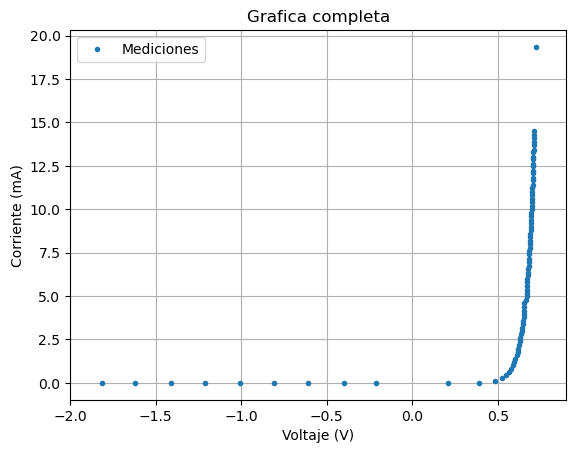

In [8]:
#Hacemos toda la grafica de I vs V
V_arr1 = np.array(Vd_inv[::-1])
V_arr2 = np.array(Vd_direc)
V_Tot = np.concatenate((V_arr1,V_arr2))
I_arr1 = np.array(Id_inv[::-1])
I_arr2 = np.array(Id_direc)
I_Tot = np.concatenate((I_arr1,I_arr2))

plt.plot(V_Tot,I_Tot,'.',label='Mediciones')
plt.title('Grafica completa')
plt.xlabel('Voltaje (V)'), plt.ylabel('Corriente (mA)')
plt.xlim([-2,0.9])
plt.grid()
plt.legend()
plt.show()